### PyTorch for Linear Regression
#### Objective: To use the PyTorch for linear regression


Linear regression is a machine learning method used to find the relationship between input data and the expected output. Its goal is to learn a simple equation that can predict output values from new input data. In PyTorch, we create a model with adjustable parameters (weights and bias) and train it using data. During training, the model continuously updates these parameters to reduce prediction errors and improve accuracy

## Import libraries 


In [1]:
# Import PyTorch and matplotlib
import torch
import matplotlib.pyplot as plt
from torch import nn # nn contains all of PyTorch's building blocks for neural networks

# Check PyTorch version
torch.__version__

'2.12.0+cu126'

## Load dataset


In [ ]:
# Setup device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cpu


In [ ]:
import pandas as pd
import torch

df = pd.read_csv(r'assignment-data (1).csv')
df.head(6)

,x,y
0,0.0,2.00
1,0.2,2.12
2,0.4,2.48
3,0.6,3.08
4,0.8,3.92
5,1.0,5.00


## Data preparation


In [ ]:
# convert to torch tensors for use in the notebook
X = torch.tensor(df['x'].values, dtype=torch.float32).unsqueeze(1)
y = torch.tensor(df['y'].values, dtype=torch.float32).unsqueeze(1)
print(X.shape)
print(y.shape)

torch.Size([50, 1])
torch.Size([50, 1])


## Data splitting


In [ ]:
# Split data
train_split = int(0.8 * len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

## Visualization of training and testing data

In [ ]:


def plot_predictions(train_data=X_train, 
                     train_labels=y_train, 
                     test_data=X_test, 
                     test_labels=y_test, 
                     predictions=None):
  """
  Plots training data, test data and compares predictions.
  """
  plt.figure(figsize=(10, 7))

  # Plot training data in blue
  plt.scatter(train_data, train_labels, c="b", s=4, label="Training data")
  
  # Plot test data in green
  plt.scatter(test_data, test_labels, c="g", s=4, label="Testing data")

  if predictions is not None:
    # Plot the predictions in red (predictions were made on the test data)
    plt.scatter(test_data, predictions, c="r", s=4, label="Predictions")

  # Show the legend
  plt.legend(prop={"size": 14});

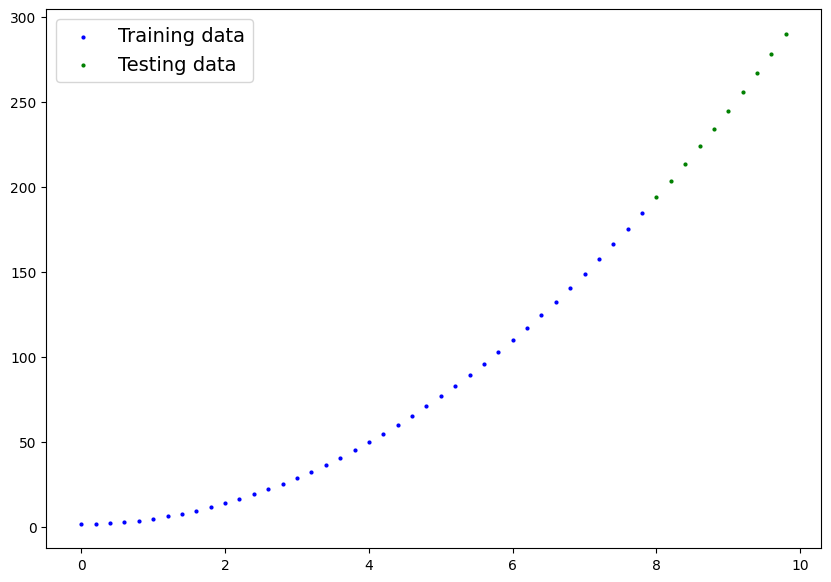

In [ ]:
plot_predictions(X_train, y_train, X_test, y_test)

### Algorithm Selection

For this project, a Linear Regression algorithm was selected and implemented using PyTorch. The model learns the relationship between the input and output data by adjusting two important values: weight and bias. These values are initially set to random numbers and are gradually improved during training. PyTorch uses an optimization process called gradient descent to automatically update these values and reduce prediction errors. The model then uses the learned weight and bias to make predictions from the given input data through a simple linear regression formula.

## Linear model class

In [ ]:
# Create a Linear Regression model class
class LinearRegressionModel(nn.Module): 
    def __init__(self):
        super().__init__() 
        self.weights = nn.Parameter(torch.randn(1, 
                                    dtype=torch.float), 
                                    requires_grad=True) 

        self.bias = nn.Parameter(torch.randn(1, 
                                dtype=torch.float),
                                requires_grad=True) 

    # Forward defines the computation in the model
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.weights * x**2 + self.bias 

### PyTorch Model Building Essentials

torch.nn – A PyTorch module that provides the building blocks needed to create machine learning and neural network models, including layers, activation functions, and loss functions.

torch.nn.Parameter – Used to define values that the model can learn during training, such as weights and biases. These values are automatically updated to improve model performance.

torch.nn.Module – The parent class for all PyTorch models. It helps organize the model structure and manage its trainable parameters.

torch.optim – A package that contains optimization algorithms, such as SGD and Adam, which adjust the model's parameters to reduce prediction errors during training.

forward() – A special method that describes how input data moves through the model and is transformed into output predictions. It represents the model's computation process.

## Model initialization and inspection of parameter

In [ ]:
# Set manual seed since nn.Parameter are randomly initialized
torch.manual_seed(42)

# Create an instance of the model (this is a subclass of nn.Module that contains nn.Parameter(s))
model_0 = LinearRegressionModel()

# Check the nn.Parameter(s) within the nn.Module subclass we created
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [ ]:
print(model_0.weights.dtype)
print(model_0.bias.dtype)

torch.float32
torch.float32


## Initial prediction

In [ ]:
# Make predictions with model
with torch.inference_mode(): 
    y_preds = model_0(X_test)

# Note: in older PyTorch code you might also see torch.no_grad()
# with torch.no_grad():
#   y_preds = model_0(X_test)

y_preds[:5]

tensor([[21.6770],
        [22.7679],
        [23.8857],
        [25.0304],
        [26.2021]])

In [ ]:
print(f"Number of testing samples: {len(X_test)}") 
print(f"Number of predictions made: {len(y_preds)}")
print(f"Predicted values:\n{y_preds}")

Number of testing samples: 10
Number of predictions made: 10
Predicted values:
tensor([[21.6770],
        [22.7679],
        [23.8857],
        [25.0304],
        [26.2021],
        [27.4007],
        [28.6263],
        [29.8788],
        [31.1582],
        [32.4646]])


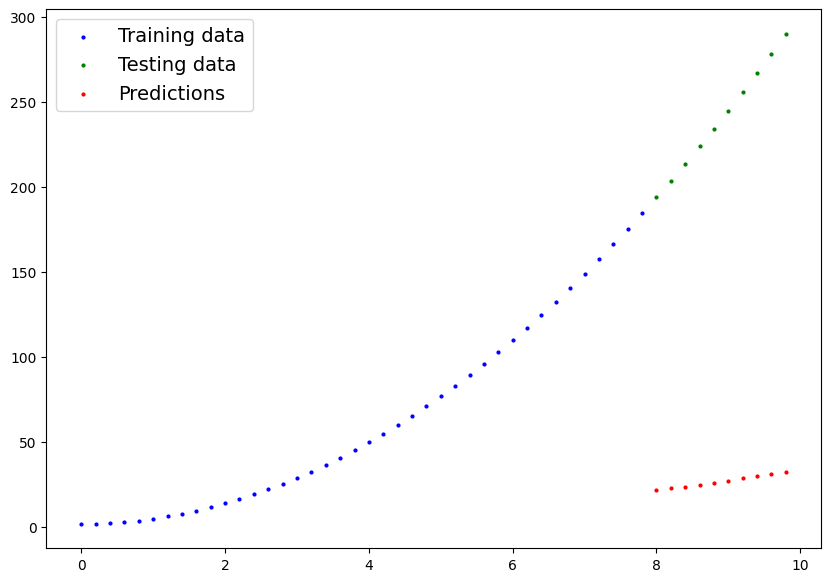

In [ ]:
plot_predictions(predictions=y_preds)

## Configure loss function and optimizer

In [ ]:
loss_fn = nn.L1Loss() 

# Create the optimizer
optimizer = torch.optim.SGD(
                    params=model_0.parameters(), lr=0.01)

### Training and Testing Loop

The model is trained for 100 epochs, where each epoch represents one complete pass through the training data. During training, the model first makes predictions using the input data, then compares those predictions with the actual values to calculate the error (loss). Based on this error, the model adjusts its weight and bias values to improve future predictions.

After each training cycle, the model is tested on a separate dataset to evaluate how well it performs on unseen data. During testing, the model's parameters are not updated, ensuring that the evaluation remains unbiased. The training loss and testing loss are recorded at regular intervals to track the model's learning progress and to check whether the model is learning effectively or starting to overfit the training data.

In [ ]:
torch.manual_seed(42)

# Set the number of epochs (how many times the model will pass over the training data)
epochs = 100

# Create empty loss lists to track values
train_loss_values = []
test_loss_values = []
epoch_count = []

for epoch in range(epochs):
    ### Training

    # Put model in training mode (this is the default state of a model)
    model_0.train()

    # 1. Forward pass on train data using the forward() method inside 
    y_pred = model_0(X_train)
    # print(y_pred)

    # 2. Calculate the loss (how different are our models predictions to the ground truth)
    loss = loss_fn(y_pred, y_train)

    # 3. Zero grad of the optimizer
    optimizer.zero_grad()

    # 4. Loss backwards
    loss.backward()

    # 5. Progress the optimizer
    optimizer.step()

    ### Testing

    # Put the model in evaluation mode
    model_0.eval()

    with torch.inference_mode():
      # 1. Forward pass on test data
      test_pred = model_0(X_test)

      # 2. Caculate loss on test data
      test_loss = loss_fn(test_pred, y_test.type(torch.float)) # predictions come in torch.float datatype, so comparisons need to be done with tensors of the same type

      # Print out what's happening every 10 epochs
      if epoch % 10 == 0:
            epoch_count.append(epoch)
            train_loss_values.append(loss.detach().numpy())
            test_loss_values.append(test_loss.detach().numpy())
            print(f"Epoch: {epoch} | MAE Train Loss: {loss} | MAE Test Loss: {test_loss} ")

Epoch: 0 | MAE Train Loss: 56.5755729675293 | MAE Test Loss: 197.36334228515625 
Epoch: 10 | MAE Train Loss: 14.286410331726074 | MAE Test Loss: 33.888160705566406 
Epoch: 20 | MAE Train Loss: 2.8425636291503906 | MAE Test Loss: 2.050981044769287 
Epoch: 30 | MAE Train Loss: 3.392380475997925 | MAE Test Loss: 0.18432006239891052 
Epoch: 40 | MAE Train Loss: 3.450094699859619 | MAE Test Loss: 0.1851348876953125 
Epoch: 50 | MAE Train Loss: 3.436321973800659 | MAE Test Loss: 0.2010147124528885 
Epoch: 60 | MAE Train Loss: 3.3256192207336426 | MAE Test Loss: 0.6358078122138977 
Epoch: 70 | MAE Train Loss: 3.336348056793213 | MAE Test Loss: 0.5997177362442017 
Epoch: 80 | MAE Train Loss: 3.586681842803955 | MAE Test Loss: 0.4443832337856293 
Epoch: 90 | MAE Train Loss: 3.900193691253662 | MAE Test Loss: 1.460443139076233 


## PLot the curve

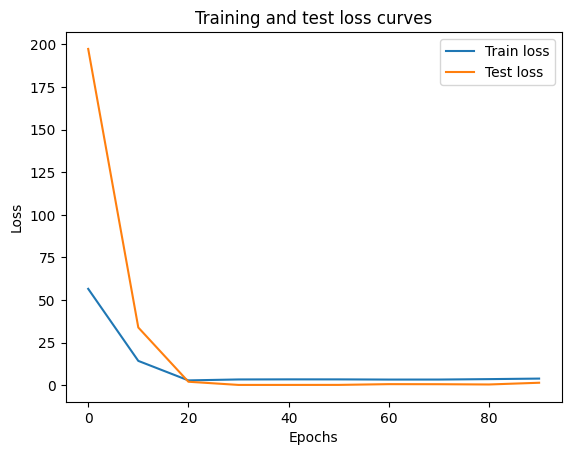

In [ ]:
# Plot the loss curves
plt.plot(epoch_count, train_loss_values, label="Train loss")
plt.plot(epoch_count, test_loss_values, label="Test loss")
plt.title("Training and test loss curves")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend();

In [ ]:
# Find our model's learned parameters
print("The model learned the following values for weights and bias:")
print(model_0.state_dict())
print("\nAnd the original values for weights and bias are:")
print(f"weights: 0.7, bias: 0.3")

The model learned the following values for weights and bias:
OrderedDict({'weights': tensor([3.0387]), 'bias': tensor([0.5983])})

And the original values for weights and bias are:
weights: 0.7, bias: 0.3


## Final prediction 

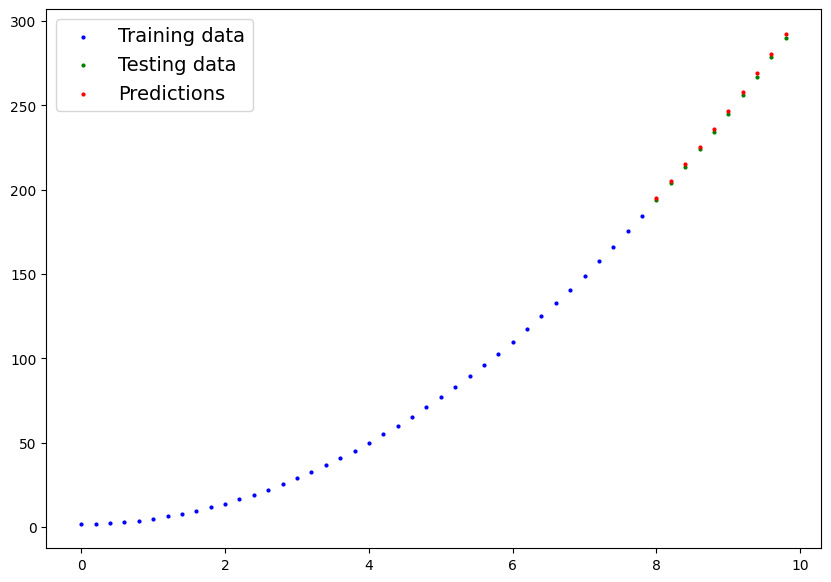

In [ ]:
# 1. Set the model in evaluation mode
model_0.eval()

# 2. Setup the inference mode context manager
with torch.inference_mode():
  # 3. Make sure the calculations are done with the model and data on the same device
  # in our case, we haven't setup device-agnostic code yet so our data and model are
  # on the CPU by default.
  # model_0.to(device)
  # X_test = X_test.to(device)
  y_preds = model_0(X_test)
plot_predictions(predictions=y_preds)

Discussion

In this experiment we investigated the process of creating and training a Linear Regression model using PyTorch. We created the Linear Regression model with trainable parameters, weight and bias, and initialized these parameters to random values, resulting in poor predictions at first. With every step during training, the model trained the weight and bias by utilizing Stochastic Gradient Descent (SGD) and back-propagation to gradually minimize the prediction error, hence improving the model's ability. The decrease of training and testing loss signifies that the model is accurately learning the relationship between the input and output data. The finalized parameter values are relatively close to the actual values that generated the data, signifying that the model has achieved stable convergence.

Conclusion

In this experiment, we have successfully created and trained a Linear Regression model using PyTorch. We trained the model to learn the underlying relationship between input and output data by iteratively minimizing the prediction errors using the optimization algorithm. After training, the model successfully predicted the output based on new input data.